In [8]:
# from xopr_gline import xopr_utils
import numpy as np
import xarray as xr
import hvplot.xarray
import matplotlib.pyplot as plt
import scipy.constants
from scipy import signal
import pandas as pd
import geopandas as gpd
import xopr.opr_access
import xopr.geometry
import dask
from dask.distributed import LocalCluster
import cartopy.crs as ccrs
import geoviews.feature as gf
import time
import requests
from scipy.optimize import curve_fit

from xopr_gline.xopr_utils import extract_layer_peak_power, surface_bed_reflection_power, get_basal_layer_wgs84
from xopr_gline.empirical import erf_topography_model, get_derivatives

In [9]:
opr = xopr.opr_access.OPRConnection(cache_dir="/tmp")

Use the `get_greenland_regions` methods to select the area of interest 

In [10]:
region = xopr.geometry.get_greenland_regions(name='PETERMANN_GLETSCHER')

Area is 71268.7 km^2, automatically applying 100m simplification tolerance
To disable simplification, set simplify_tolerance=0


In [11]:
# get a specific line from Petermann
stac_items = opr.query_frames(geometry=region, date_range="2006/2015")

# if we know the specific segment we can query like this 
# # stac_items = opr.query_frames(segment_paths='20100420_03')

In [12]:
# get a specific line from Petermann
# stac_items = opr.query_frames(geometry=region, date_range="2006/2015")

# if we know the specific segment we can query like this 
# # stac_items = opr.query_frames(segment_paths='20100420_03')

In [13]:
stac_items

,collection,geometry,properties,assets,bbox,id,links,stac_extensions,stac_version,type
stac_item_id,,,,,,,,,,
Data_20100324_03_001,2010_Greenland_DC8,"LINESTRING (-58.08389 79.80457, -55.86274 80.033)",{'datetime': '2010-03-24T16:14:03.359969+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-58.0838913346226, 79.80456620860271, -55.862...",Data_20100324_03_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100324_03_002,2010_Greenland_DC8,"LINESTRING (-55.95165 80.02441, -53.43301 80.2...",{'datetime': '2010-03-24T16:20:23.233475+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-55.95165185181729, 80.02441167320681, -53.25...",Data_20100324_03_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100324_02_001,2010_Greenland_DC8,"LINESTRING (-53.76708 80.30466, -56.09652 80.0...",{'datetime': '2010-03-24T15:59:00.290657+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-56.09651878913258, 80.09079202858838, -53.76...",Data_20100324_02_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100324_02_002,2010_Greenland_DC8,"LINESTRING (-56.00761 80.09947, -58.47365 79.8...",{'datetime': '2010-03-24T16:05:07.406478+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-58.60251409020991, 79.82741415447454, -56.00...",Data_20100324_02_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20100330_02_002,2010_Greenland_DC8,"LINESTRING (-51.85578 77.69656, -49.88874 77.9...",{'datetime': '2010-03-30T12:05:28.740629+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-51.855783398410466, 77.69656086664922, -49.8...",Data_20100330_02_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
...,...,...,...,...,...,...,...,...,...,...
Data_20150506_02_010,2015_Greenland_C130,"LINESTRING (-58.41131 79.11811, -57.4816 79.53...",{'datetime': '2015-05-06T12:04:17.333756+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-58.41131285300399, 79.11811138831048, -57.48...",Data_20150506_02_010,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20150506_02_011,2015_Greenland_C130,"LINESTRING (-57.48094 79.53122, -56.47761 79.9...",{'datetime': '2015-05-06T12:10:45.384692+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-57.48094102753004, 79.53121840285041, -56.47...",Data_20150506_02_011,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature
Data_20150506_02_012,2015_Greenland_C130,"LINESTRING (-56.47687 79.94156, -55.39241 80.3...",{'datetime': '2015-05-06T12:17:14.042426+00:00...,{'CSARP_standard': {'href': 'https://data.cres...,"[-56.4768690743136, 79.94155898957753, -55.392...",Data_20150506_02_012,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature


From prior work, I already know I want this `Data_20100420_03_009` so we can `loc` the dataframe to pull that specific row

In [14]:
stac_id = 'Data_20100420_03_009'
petermann_line_stac = stac_items.loc[stac_id]
petermann_line_stac

collection                                        2010_Greenland_DC8
geometry           LINESTRING (-61.27258317305416 80.921537413055...
properties         {'datetime': '2010-04-20T18:17:04.516143+00:00...
assets             {'CSARP_standard': {'href': 'https://data.cres...
bbox               [-61.27258317305416, 80.54199019372452, -59.70...
id                                              Data_20100420_03_009
links                                                             []
stac_extensions    [https://stac-extensions.github.io/file/v2.1.0...
stac_version                                                   1.1.0
type                                                         Feature
Name: Data_20100420_03_009, dtype: object

In [16]:
# petermann_line_string = gpd.GeoSeries(petermann_line_stac['geometry'], crs=4326)
# petermann_line_string.to_file('/home/laserglaciers/petermann_grounding_zones/petermann_Data_20100420_03_009.gpkg',
#                               driver='GPKG')

In [17]:
petermann_line_stac['assets']

{'CSARP_standard': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/CSARP_standard/20100420_03/Data_20100420_03_009.mat',
  'type': 'application/x-matlab-data'},
 'data': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/CSARP_standard/20100420_03/Data_20100420_03_009.mat',
  'type': 'application/x-matlab-data'},
 'flight_path': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/images/20100420_03/20100420_03_009_0maps.jpg',
  'type': 'image/jpeg'},
 'thumbnails': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/images/20100420_03/20100420_03_009_2echo_picks.jpg',
  'type': 'image/jpeg'},
 'CSARP_layer': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/CSARP_layer/20100420_03/Data_20100420_03_009.mat',
  'type': 'application/x-matlab-data'},
 'CSARP_mvdr': {'href': 'https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/CSARP_mvdr/20100420_03/Data_20100420_03_009.mat',
  'type': 'application/x-matlab-data'}}

In [18]:
# We need to get the layer file to exctact the radargram
try:
    layers = opr.get_layers(petermann_line_stac)
    
except Exception as e:
    print(f"Error retrieving layers: {e}")
    
#convert to elevation
for layer_idx in layers:
    layers[layer_idx] = xopr.radar_util.add_along_track(layers[layer_idx])
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='wgs84')
    layers[layer_idx] = xopr.layer_twtt_to_range(layers[layer_idx], layers["standard:surface"], vertical_coordinate='range')

In [19]:
frame_1 = opr.load_frame(petermann_line_stac)
frame_1 = xopr.radar_util.add_along_track(frame_1)
frame_1 = xopr.radar_util.interpolate_to_vertical_grid(frame_1, vertical_coordinate='wgs84')

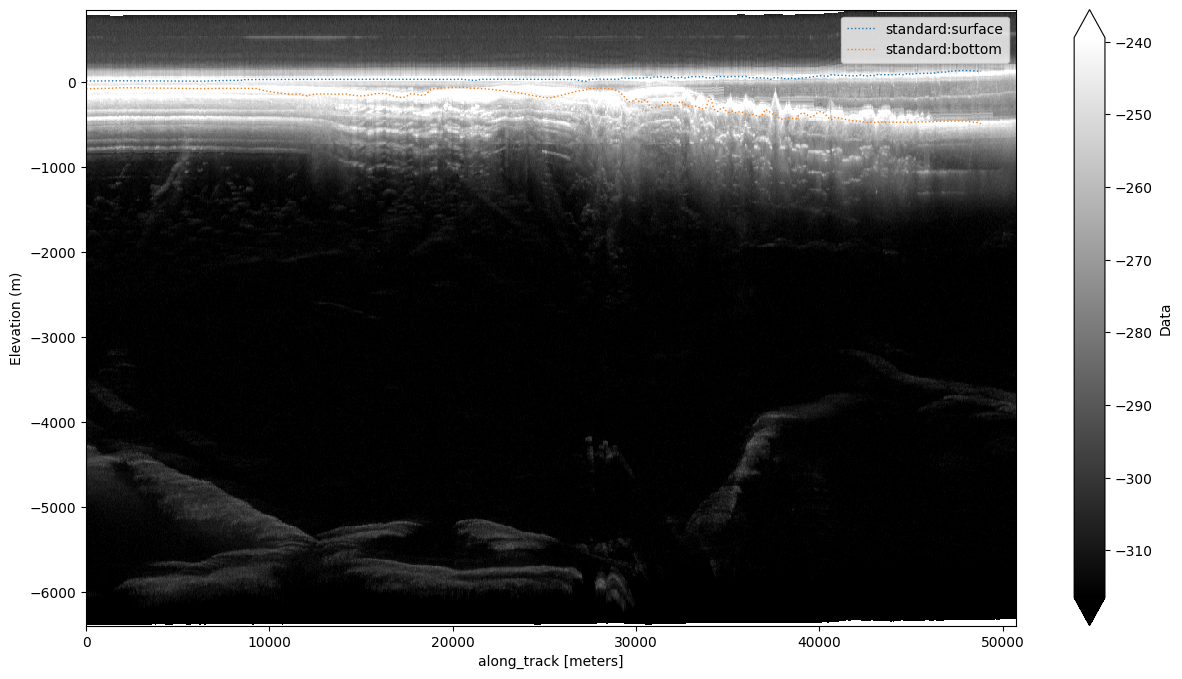

In [20]:
# visualize radargram

clb_min_pct, clb_max_pct = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(frame_1.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=vmin_1, vmax=vmax_1)

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()

Add in grounding zone data from Ciracì et al 2023 (https://pnas.org/doi/10.1073/pnas.2220924120)

In [21]:
gz_path = '../data/petermann_grounding_zones.geojson'
gz_gdf = gpd.read_file(gz_path)
gz_gdf.crs

<Projected CRS: EPSG:3413>
Name: WGS 84 / NSIDC Sea Ice Polar Stereographic North
Axis Info [cartesian]:
- X[south]: Easting (metre)
- Y[south]: Northing (metre)
Area of Use:
- name: Northern hemisphere - north of 60°N onshore and offshore, including Arctic.
- bounds: (-180.0, 60.0, 180.0, 90.0)
Coordinate Operation:
- name: US NSIDC Sea Ice polar stereographic north
- method: Polar Stereographic (variant B)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [22]:
layers['standard:surface']

<xarray.Dataset> Size: 220kB
Dimensions:       (slow_time: 3335)
Coordinates:
  * slow_time     (slow_time) datetime64[ns] 27kB 2010-04-20T18:14:32.6790719...
    along_track   (slow_time) float64 27kB 0.0 14.64 ... 4.881e+04 4.882e+04
Data variables:
    file_type     <U5 20B 'layer'
    file_version  <U1 4B '1'
    elev          (slow_time) float64 27kB 478.7 478.6 478.6 ... 522.4 522.4
    id            float64 8B 1.0
    Latitude      (slow_time) float64 27kB 80.91 80.91 80.91 ... 80.55 80.55
    Longitude     (slow_time) float64 27kB -61.24 -61.24 ... -59.73 -59.73
    quality       (slow_time) uint8 3kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    twtt          (slow_time) float64 27kB 3.133e-06 3.133e-06 ... 2.657e-06
    type          (slow_time) uint8 3kB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2 2
    wgs84         (slow_time) float64 27kB 9.068 9.013 8.957 ... 124.2 124.1
    range         (slow_time) float64 27kB 469.6 469.6 469.6 ... 398.2 398.3
Attributes:
    source_url:  https://data.cresis.ku.edu/data/rds/2010_Greenland_DC8/CSARP...

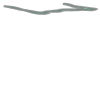

In [23]:
gz_gdf_4326 = gz_gdf.to_crs(4326)
gz_gdf_4326[gz_gdf_4326['layer'] == '2011_2015']
gz_2011 = gz_gdf_4326[gz_gdf_4326['layer'] == '2011_2015']
gz_2011['geometry'][0]

In [24]:
segment_geom = petermann_line_stac['geometry']
segment_geom = segment_geom.intersection(gz_2011['geometry'][0])
segment_geom_coords = list(segment_geom.coords)
# segment_geom_coords
segment_geom_coords = np.array(segment_geom_coords)
lons = segment_geom_coords[:,0]
lats = segment_geom_coords[:,1]
lats

array([80.56916742, 80.5525651 ])

<Axes: >

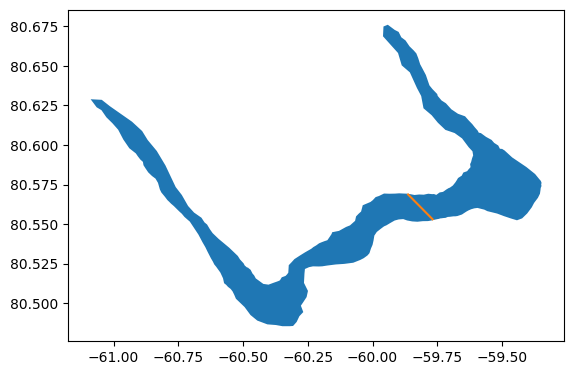

In [25]:
fig, ax = plt.subplots()
segment_geom_gpd = gpd.GeoSeries(segment_geom)
segment_geom_gpd.plot(ax=ax, color='tab:orange')
gz_2011.plot(ax=ax)
# ax.get_xlim()

In [26]:
from shapely.geometry import Point, LineString

segment_line = gpd.GeoSeries(petermann_line_stac['geometry'], crs=4326)
segment_line = segment_line.to_crs(3413)

# Interpolate points every 2 units
distances = np.arange(0, segment_line[0].length, 2)
# points = segment_line.interpolate(distances)
# points
len(distances)

25360

In [27]:
def interpolate_points_along_line(geoSeries):
    distances = np.arange(0, geoSeries[0].length, 2)
    line = geoSeries.geometry
    # Filter out distances greater than the line length if necessary
    # valid_distances = distances[distances <= line.length]
    points = [line.interpolate(distance) for distance in distances]
    
    return points

pts = interpolate_points_along_line(segment_line)
len(pts)

25360

In [28]:
segment_line[0].length
# distances

50718.62960300486

In [29]:
frame_1 = frame_1.assign_coords({"Latitude": frame_1["Latitude"]})
frame_1 = frame_1.assign_coords({"Longitude": frame_1["Longitude"]})
frame_1['along_track'].data[-1]

np.float64(50727.79672412107)

In [30]:
frame_1

<xarray.Dataset> Size: 10MB
Dimensions:      (slow_time: 3537, wgs84: 724, twtt: 769)
Coordinates:
  * slow_time    (slow_time) datetime64[ns] 28kB 2010-04-20T18:14:08.30970859...
  * wgs84        (wgs84) float64 6kB -6.387e+03 -6.377e+03 ... 832.8 842.8
  * twtt         (twtt) float64 6kB -1.999e-06 -1.894e-06 ... 7.889e-05
    along_track  (slow_time) float64 28kB 0.0 14.15 ... 5.071e+04 5.073e+04
    Latitude     (slow_time) float64 28kB 80.92 80.92 80.92 ... 80.54 80.54
    Longitude    (slow_time) float64 28kB -61.27 -61.27 -61.27 ... -59.7 -59.7
Data variables:
    Data         (slow_time, wgs84) float32 10MB -1.0 3.043e-35 ... -2.0 -2.0
    Time         (twtt) float64 6kB -1.999e-06 -1.894e-06 ... 7.889e-05
    GPS_time     (slow_time) float64 28kB 1.272e+09 1.272e+09 ... 1.272e+09
    Elevation    (slow_time) float64 28kB 484.5 484.5 484.5 ... 527.6 527.6
    Surface      (slow_time) float64 28kB 3.191e-06 3.163e-06 ... 2.696e-06
Attributes: (12/29)
    source_url:             https://data.cresis.ku.edu/data/rds/2010_Greenlan...
    Conventions:            CF-1.8
    title:                  Radar Echogram Data
    institution:            Open Polar Radar (OPR)
    source:                 Airborne/ground-based radar sounder
    history:                Converted to CF-compliant format on 2026-02-13T20...
    ...                     ...
    param_combine_wf_chan:  {'in_path': array([], dtype='<U1'), 'array_path':...
    Depth:                  [-2.99642562e+02 -2.83855507e+02 -2.68068451e+02 ...
    param_records:          {'file': {'adcs': array([1, 2, 3, 4, 5, 6, 7, 8],...
    param_csarp:            {'file': {'base_dir': '/cresis/data2/MCoRDS/2010_...
    param_radar:            {'rx_path': [{'chan_equal': (-0.7808891282744658-...
    Bottom:                 [4.25237656e-06 4.25238608e-06 4.25236893e-06 ......

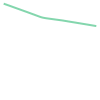

In [31]:
frame_1_proj = xopr.geometry.project_dataset(frame_1, "EPSG:3413")
xy_points = gpd.points_from_xy(frame_1_proj['x'], frame_1_proj['y'])
lon_lat_points = gpd.points_from_xy(frame_1['Longitude'], frame_1['Latitude'])

frame_linestring_3413 = LineString(xy_points)
frame_linestring_4326 = LineString(lon_lat_points)
frame_linestring_4326

<Axes: >

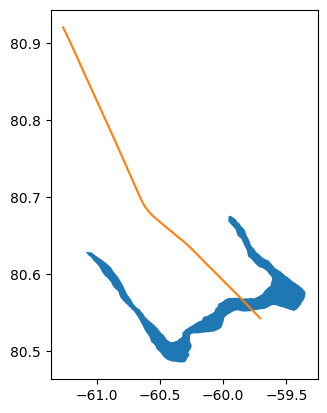

In [32]:
fig, ax = plt.subplots()
segment_geom_gpd = gpd.GeoSeries(frame_linestring_4326)
segment_geom_gpd.plot(ax=ax, color='tab:orange')
gz_2011.plot(ax=ax)
# ax.get_xlim()

In [33]:

segment_geom = segment_geom_gpd[0].intersection(gz_2011['geometry'][0])
# segment_geom
segment_geom_coords = list(segment_geom.coords)
# segment_geom_coords
segment_geom_coords = np.array(segment_geom_coords)
lons = segment_geom_coords[:,0]
lats = segment_geom_coords[:,1]
lons[0]

np.float64(-59.862946967824634)

In [34]:
slow_time_lat1 = frame_1.swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[0], method='nearest')['slow_time']
slow_time_lat2 = frame_1.swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[-1], method='nearest')['slow_time']
print(f'slow_time lat 1: {slow_time_lat1.data}\nslow_time lat 2: {slow_time_lat2.data}')


slow_time lat 1: 2010-04-20T18:19:28.694723129
slow_time lat 2: 2010-04-20T18:19:45.425940514


In [35]:
slow_time_lon1 = frame_1.swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[0], method='nearest')['slow_time']
slow_time_lon2 = frame_1.swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[-1], method='nearest')['slow_time']
print(f'slow_time lon 1: {slow_time_lon1.data}\nslow_time lon 2: {slow_time_lon2.data}')

slow_time lon 1: 2010-04-20T18:19:28.694723129
slow_time lon 2: 2010-04-20T18:19:45.425940514


In [36]:
along_track_lon1 = frame_1['along_track'].sel(slow_time=slow_time_lon1)
along_track_lon2 = frame_1['along_track'].sel(slow_time=slow_time_lon1)

along_track_lat1 = frame_1['along_track'].sel(slow_time=slow_time_lat1)
along_track_lat2 = frame_1['along_track'].sel(slow_time=slow_time_lat2)

print(f'lon 1 {along_track_lon1.data} ...... lat 1 {along_track_lat1.data}')

lon 1 46598.124806413725 ...... lat 1 46598.124806413725


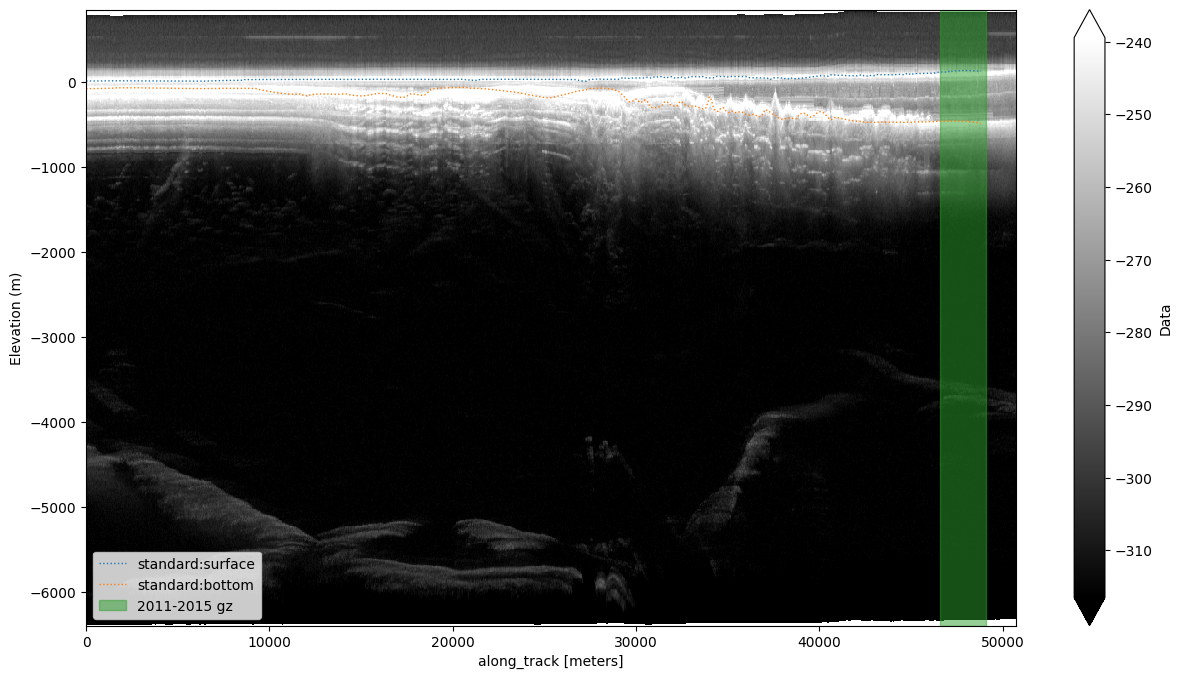

In [37]:
# visualize radargram

clb_min_pct, clb_max_pct = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(frame_1.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=vmin_1, vmax=vmax_1)

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)


ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')

# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()

In [38]:
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Latitude": layers['standard:surface']["Latitude"]})
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Longitude": layers['standard:surface']["Longitude"]})

layers['standard:surface']['along_track'].data[-1]

np.float64(48822.33963820429)

In [39]:
# layers['standard:surface'] = layers['standard:surface'].assign_coords({"Latitude": layers['standard:surface']["Latitude"]})
slow_time_lat1 = layers['standard:surface'].swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[0], method='nearest')['slow_time']
slow_time_lat2 = layers['standard:surface'].swap_dims({'slow_time': 'Latitude'}).sel(Latitude=lats[1], method='nearest')['slow_time']
print(f'slow_time lat 1: {slow_time_lat1.data}\nslow_time lat 2: {slow_time_lat2.data}')

slow_time lat 1: 2010-04-20T18:19:43.817803144
slow_time lat 2: 2010-04-20T18:19:43.817803144


In [40]:
layers['standard:surface'] = layers['standard:surface'].assign_coords({"Longitude": layers['standard:surface']["Longitude"]})
slow_time_lon1 = layers['standard:surface'].swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[0], method='nearest')['slow_time']
slow_time_lon2 = layers['standard:surface'].swap_dims({'slow_time': 'Longitude'}).sel(Longitude=lons[1], method='nearest')['slow_time']
print(f'slow_time lon 1: {slow_time_lon1.data}\nslow_time lon 2: {slow_time_lon2.data}')

slow_time lon 1: 2010-04-20T18:19:43.817803144
slow_time lon 2: 2010-04-20T18:19:43.817803144


In [41]:
layers['standard:surface'].indexes

Indexes:
    slow_time  DatetimeIndex(['2010-04-20 18:14:32.679071903',
               '2010-04-20 18:14:32.784679651',
               '2010-04-20 18:14:32.890281200',
               '2010-04-20 18:14:32.995877981',
               '2010-04-20 18:14:33.101469994',
               '2010-04-20 18:14:33.207065821',
               '2010-04-20 18:14:33.312666655',
               '2010-04-20 18:14:33.418246984',
               '2010-04-20 18:14:33.523816823',
               '2010-04-20 18:14:33.629376888',
               ...
               '2010-04-20 18:20:06.302265644',
               '2010-04-20 18:20:06.399687767',
               '2010-04-20 18:20:06.497106791',
               '2010-04-20 18:20:06.594522953',
               '2010-04-20 18:20:06.691936493',
               '2010-04-20 18:20:06.789347172',
               '2010-04-20 18:20:06.886754274',
               '2010-04-20 18:20:06.984158516',
               '2010-04-20 18:20:07.081559420',
               '2010-04-20 18:20:07.178958416

In [42]:
len(layers['standard:surface']["Longitude"])

3335

In [43]:
# Get power (dB) of surface and bed
reflectivity = surface_bed_reflection_power(petermann_line_stac, opr=opr)
reflectivity = xopr.radar_util.add_along_track(reflectivity)


/home/m484s199/xopr-gline/src/xopr_gline/xopr_utils.py:82: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'slow_time' ('slow_time',) The recommendation is to set join explicitly for this case.
  reflectivity_dataset = xr.merge([reflectivity_dataset, flight_line_metadata])


Let's try a very simple approach first and just find the peak change in the bed power for a transition between grounded to floating

In [44]:
bed_power_grad = np.gradient(reflectivity['bed_power_dB']) # the Xia paper takes the second derivative but that looks worse
reflectivity['bed_power_grad'] = (('slow_time'), bed_power_grad)

# get the index of the peak bed power and grab the bed elevation index too
grad_max_idx = reflectivity['bed_power_grad'].argmax(dim="slow_time").data
grad_max = reflectivity['bed_power_grad'].max()

grad_slowtime = reflectivity['bed_power_grad']['slow_time'][grad_max_idx]
bed_point = layers['standard:bottom']['wgs84'].sel(slow_time=grad_slowtime.data, method='nearest')

In [45]:
grad_max_slowtime = reflectivity['slow_time'].max(dim="slow_time").data

In [46]:
bottom_gp = layers[layer_name]['wgs84'].sel(slow_time=grad_max_slowtime, method='nearest')
bottom_gp

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-464.43114571)
Coordinates:
    slow_time    datetime64[ns] 8B 2010-04-20T18:19:54.977114201
    along_track  float64 8B 4.699e+04
Attributes:
    units:        meters
    description:  WGS84 elevation of layer

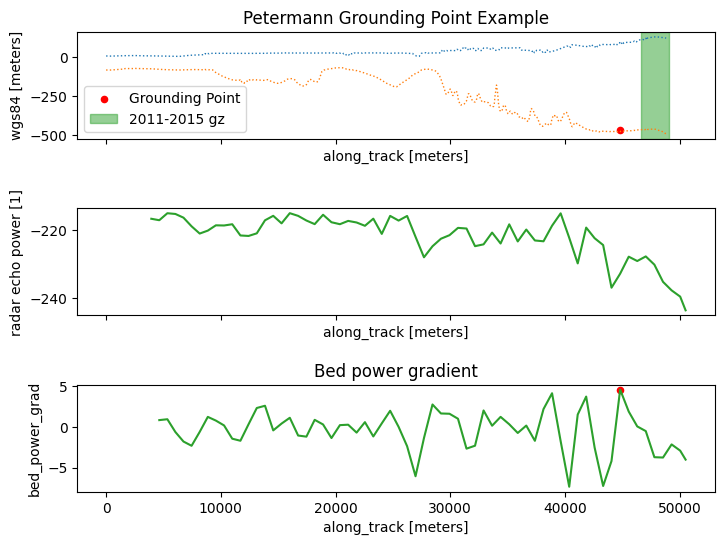

In [47]:
# Plot layers using elevation data and slow_time
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8,6), sharex=True)
fig.tight_layout(pad=4.0)

for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':')#, label=layer_name)

ax1.scatter(reflectivity['along_track'][grad_max_idx], bottom_gp, color='r', s=20, label="Grounding Point")
ax1.set_title('Petermann Grounding Point Example')

ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')


reflectivity['bed_power_dB'].plot(ax=ax2, x='along_track', label='Bed Power dB', color='tab:green')
# ax3.scatter(grad_slowtime, grad_max, color='r', s=20, label="Grounding Point")


# Plot layers using elevation data
#ax3 plot
reflectivity['bed_power_grad'].plot(ax=ax3, x='along_track', label='bed_grad', color='tab:green')
ax3.scatter(reflectivity['along_track'][grad_max_idx], grad_max, color='r', s=20, label="Grounding Point")

ax1.legend()
# ax3.legend()
ax3.set_title('Bed power gradient')
fig.savefig('/home/m484s199/gline_figures/petermann_20100420_layers.png', dpi=300)

**Issue**: Need to figure out how to make these both along track for the X

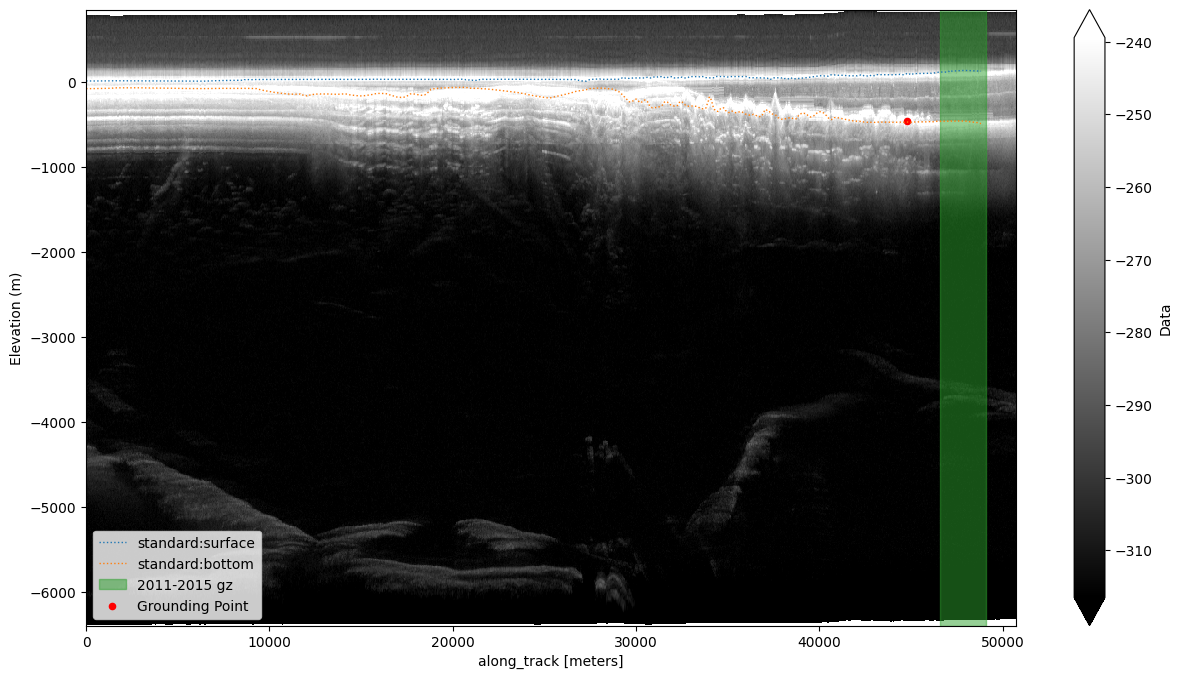

In [48]:
# visualize radargram

clb_min_pct, clb_max_pct = 30, 97

# Plot radargrams in elevation coordinates with layers
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 8))

# Frame 1 radargram in elevation
pwr_1_elev = 10*np.log10(np.abs(frame_1.Data))
vmax_1 = np.percentile(pwr_1_elev, clb_max_pct)
vmin_1 = np.percentile(pwr_1_elev, clb_min_pct)
pwr_1_elev.plot.imshow(x='along_track', y='wgs84', cmap='gray', ax=ax1, vmin=vmin_1, vmax=vmax_1)

# Plot layers using elevation data
for layer_name in layers:
    layers[layer_name]['wgs84'].plot(ax=ax1, x='along_track', linewidth=1, linestyle=':', label=layer_name)


ax1.axvspan(along_track_lat1.data, along_track_lat2.data, color='tab:green',
            alpha=0.5, label='2011-2015 gz')

ax1.scatter(reflectivity['along_track'][grad_max_idx], bottom_gp, color='r', s=20, label="Grounding Point")
# ax1.set_title(f"{intersect['collection_1']} - {intersect['id_1']} (Elevation view)")
ax1.set_ylabel('Elevation (m)')
ax1.legend()
fig.savefig('/home/m484s199/gline_figures/petermann_20100420_frame.png', dpi=300)

In [187]:
bed_point

<xarray.DataArray 'wgs84' ()> Size: 8B
array(-425.34510601)
Coordinates:
    slow_time    datetime64[ns] 8B 2010-04-20T18:19:14.969641685
    along_track  float64 8B 4.103e+04
Attributes:
    units:        meters
    description:  WGS84 elevation of layer